# 3. Working With Data & Visualisation

By the end of this session you should be able to:
- Load data into a Pandas DataFrame from a CSV file and inspect its contents
- Use basic built-in Pandas operations
- Create plots using Matplotlib (line plots, scatter plots, histograms)

## Loading data with Pandas

When working with data, you will mostly encounter data stored in plain text formats. The two most common are:

- CSV (Comma-Separated Values): tabular data where each row is a line and each column is separated by a comma
- TXT: plain text files, which may use other delimiters such as spaces or tabs

The most used Python library for loading and working with tabular data is Pandas (see https://pandas.pydata.org/docs/index.html for the documentation). Pandas represents data as a DataFrame, which is a two-dimensional table with labelled rows and columns, similar to a spreadsheet. To load a CSV file into a DataFrame you use the `.read_csv()` function, where you are required to specify the path to the file containing the data.

In [5]:
import pandas as pd

The dataset we will use is NASA's Global Surface Temperature Analysis (GISTEMP), which records monthly global mean temperature anomalies relative to the 1951–1980 average, from 1880 to the present. It is publicly available from NASA GISS. Before we begin, download the dataset from NASA GISS:

1. Go to https://data.giss.nasa.gov/gistemp/data_v4.html
2. Under **Tables of Global and Hemispheric Monthly Means and Zonal Annual Means**, click CSV next to Global-mean monthly, seasonal, and annual means
3. Save the file (right-click on the link and select "Download Linked File") as GLB.Ts+dSST.csv in the same folder as this notebook

In [32]:
df = pd.read_csv('GLB.Ts+dSST.csv', skiprows=1) # skiprows skips the first row of the file
                                                # which contains a header comment rather than column names

**Note:** `.txt` files can also be loaded with `pd.read_csv()` by specifying the delimiter via the sep argument (e.g. `sep="\s+"` for whitespace-separated files). However, they may require additional arguments depending on the file's structure.

## Analysing Data with Pandas

To visualise a DataFrame, we can use `.head()`, where the first 5 rows of data will be shown by default.

In [33]:
df.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-0.25,-0.09,-0.16,-0.10,-0.21,-0.19,-.10,-.15,-.24,-.22,-.18,-.17,***,***,-0.12,-.17,-.20
1,1881,-0.20,-0.14,0.03,0.05,0.06,-0.19,0.00,-.04,-.15,-.21,-.19,-.07,-.09,-.10,-.17,0.05,-.08,-.18
2,1882,0.16,0.14,0.05,-0.16,-0.14,-0.22,-0.16,-.08,-.15,-.23,-.17,-.36,-.11,-.09,.07,-0.08,-.15,-.18
3,1883,-0.29,-0.36,-0.12,-0.18,-0.17,-0.07,-0.07,-.14,-.22,-.11,-.24,-.11,-.17,-.19,-.34,-0.16,-.09,-.19
4,1884,-0.13,-0.08,-0.36,-0.39,-0.33,-0.35,-0.30,-.28,-.27,-.25,-.33,-.31,-.28,-.26,-.11,-0.36,-.31,-.28


You can also visualise the last 5 rows using `.tail()`.

In [34]:
df.tail()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
142,2022,0.91,0.89,1.04,0.83,0.84,0.92,0.94,.94,.88,.97,.73,.80,.89,.90,.89,0.90,.93,.86
143,2023,0.87,0.96,1.23,0.98,0.94,1.08,1.19,1.19,1.48,1.34,1.40,1.35,1.17,1.12,.88,1.05,1.16,1.41
144,2024,1.25,1.44,1.39,1.31,1.16,1.23,1.20,1.30,1.21,1.35,1.30,1.27,1.28,1.29,1.35,1.29,1.24,1.29
145,2025,1.38,1.26,1.37,1.24,1.08,1.07,1.02,1.18,1.25,1.19,1.21,1.06,1.19,1.21,1.30,1.23,1.09,1.22
146,2026,1.08,1.24,1.32,1.17,1.13,1.18,1.23,***,***,***,***,***,***,***,1.13,1.21,***,***


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    147 non-null    int64  
 1   Jan     147 non-null    float64
 2   Feb     147 non-null    float64
 3   Mar     147 non-null    float64
 4   Apr     147 non-null    float64
 5   May     147 non-null    float64
 6   Jun     147 non-null    float64
 7   Jul     147 non-null    float64
 8   Aug     147 non-null    str    
 9   Sep     147 non-null    str    
 10  Oct     147 non-null    str    
 11  Nov     147 non-null    str    
 12  Dec     147 non-null    str    
 13  J-D     147 non-null    str    
 14  D-N     147 non-null    str    
 15  DJF     147 non-null    str    
 16  MAM     147 non-null    float64
 17  JJA     147 non-null    str    
 18  SON     147 non-null    str    
dtypes: float64(8), int64(1), str(10)
memory usage: 21.9 KB


In [36]:
df.describe()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,MAM
count,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000
mean,1953.000000,0.084966,0.094082,0.112857,0.084694,0.072925,0.061701,0.084966,0.090000
std,42.579338,0.451886,0.458510,0.466171,0.426162,0.403511,0.405619,0.388283,0.427699
min,1880.000000,-0.810000,-0.630000,-0.630000,-0.590000,-0.550000,-0.520000,-0.510000,-0.580000
25%,1916.500000,-0.245000,-0.230000,-0.225000,-0.245000,-0.235000,-0.250000,-0.190000,-0.255000
50%,1953.000000,-0.010000,-0.030000,0.030000,0.000000,-0.030000,-0.050000,-0.030000,0.000000
75%,1989.500000,0.330000,0.400000,0.355000,0.305000,0.295000,0.280000,0.310000,0.320000
max,2026.000000,1.380000,1.440000,1.390000,1.310000,1.160000,1.230000,1.230000,1.290000


Some other commands:
- `.shape`: number of rows and columns
- `.columns`: see the column names
- `.dtypes`: see the data type of each column

Individual rows can be accessed by their index using `.loc[]`, although we will not use row access extensively in this session. To access specific columns of a DataFrame:

In [37]:
df["Jan"]

0     -0.19
1     -0.20
2      0.16
3     -0.29
4     -0.13
       ... 
142    0.91
143    0.87
144    1.25
145    1.38
146    1.08
Name: Jan, Length: 147, dtype: float64

In [38]:
df[["Feb", "Mar"]] # note that you need double square brackets

,Feb,Mar
0,-0.25,-0.09
1,-0.14,0.03
2,0.14,0.05
3,-0.36,-0.12
4,-0.08,-0.36
...,...,...
142,0.89,1.04
143,0.96,1.23
144,1.44,1.39
145,1.26,1.37


In [39]:
df["January"]

KeyError: 'January'

Sometimes you will encounter issues with the DataFrame entries such as missing data. Before performing operations on a DataFrame, you might need to clean the data.

In [40]:
# replace missing placeholders
df.replace("***", pd.NA, inplace=True)

# drop rows where annual mean is missing
df_clean = df.dropna(subset=["J-D"])
df_clean["J-D"] = pd.to_numeric(df_clean["J-D"])

You can also filter according to conditions:

In [41]:
# years that had a positive annual temperature anomaly
df_clean[df_clean["J-D"] > 0]

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
60,1940,-0.01,0.08,0.09,0.17,0.10,0.11,0.12,.06,.15,.11,.16,.31,0.12,.13,.16,0.12,.10,.14
61,1941,0.17,0.30,0.10,0.16,0.16,0.12,0.21,.14,.02,.35,.22,.21,0.18,.19,.26,0.14,.16,.20
62,1942,0.28,0.02,0.05,0.09,0.11,0.04,0.00,-.04,-.03,.01,.09,.12,0.06,.07,.17,0.08,.00,.02
63,1943,-0.01,0.17,-0.04,0.11,0.06,-0.05,0.08,.00,.05,.23,.19,.23,0.09,.08,.09,0.04,.01,.16
64,1944,0.36,0.24,0.26,0.19,0.18,0.15,0.17,.18,.28,.26,.11,.04,0.20,.22,.27,0.21,.17,.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,2021,0.81,0.64,0.89,0.76,0.79,0.85,0.92,.81,.92,.98,.92,.88,0.85,.84,.75,0.81,.86,.94
142,2022,0.91,0.89,1.04,0.83,0.84,0.92,0.94,.94,.88,.97,.73,.80,0.89,.90,.89,0.90,.93,.86
143,2023,0.87,0.96,1.23,0.98,0.94,1.08,1.19,1.19,1.48,1.34,1.40,1.35,1.17,1.12,.88,1.05,1.16,1.41
144,2024,1.25,1.44,1.39,1.31,1.16,1.23,1.20,1.30,1.21,1.35,1.30,1.27,1.28,1.29,1.35,1.29,1.24,1.29


In [42]:
# data from 1980 onwards
df_clean[df_clean["Year"] >= 1980]

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
100,1980,0.30,0.39,0.29,0.29,0.35,0.20,0.22,.18,.20,.13,.29,.21,0.26,.28,.39,0.31,.20,.21
101,1981,0.53,0.42,0.48,0.32,0.24,0.29,0.32,.35,.14,.12,.23,.41,0.32,.30,.39,0.35,.32,.16
102,1982,0.05,0.15,0.03,0.15,0.18,0.06,0.14,.03,.14,.13,.18,.42,0.14,.14,.20,0.12,.08,.15
103,1983,0.53,0.43,0.42,0.27,0.34,0.23,0.18,.36,.37,.17,.30,.16,0.31,.33,.46,0.34,.26,.28
104,1984,0.31,0.14,0.26,0.05,0.33,0.02,0.19,.19,.21,.13,.06,-.05,0.15,.17,.20,0.21,.14,.14
105,1985,0.22,-0.04,0.17,0.12,0.14,0.15,0.04,.17,.13,.11,.05,.14,0.12,.10,.04,0.15,.12,.10
106,1986,0.26,0.37,0.30,0.22,0.21,0.12,0.11,.15,.03,.15,.10,.13,0.18,.18,.25,0.24,.13,.09
107,1987,0.32,0.43,0.18,0.24,0.25,0.35,0.40,.25,.35,.33,.29,.46,0.32,.29,.29,0.23,.33,.32
108,1988,0.57,0.44,0.51,0.42,0.44,0.40,0.33,.39,.37,.37,.12,.29,0.39,.40,.49,0.46,.38,.29
109,1989,0.12,0.29,0.36,0.29,0.17,0.15,0.34,.33,.34,.29,.20,.37,0.27,.27,.24,0.27,.28,.28


DataFrame columns behave similarly to NumPy arrays. You can perform arithmetic operations directly on them:

In [43]:
# the dataset stores anomalies in units of 0.01°C, we convert to °C
df_clean["J-D"] / 100

# add a new column with the anomaly in °C
df_clean["Annual_C"] = df_clean["J-D"] / 100

In [44]:
# average of two months
df_clean["Jan_Feb_mean"] = (df_clean["Jan"] + df_clean["Feb"]) / 2

Pandas provides built-in methods for common summary statistics, which can be applied directly to a column:

In [45]:
print("Mean anomaly:", df_clean["Annual_C"].mean())
print("Max anomaly: ", df_clean["Annual_C"].max())
print("Min anomaly: ", df_clean["Annual_C"].min())

Mean anomaly: 0.0008232876712328765
Max anomaly:  0.0128
Min anomaly:  -0.0049


`groupby` allows you to split the data into groups and apply an aggregation function to each group. For example, to compute the average annual temperature anomaly per decade:

In [46]:
# create a decade column
df_clean["Decade"] = (df_clean["Year"] // 10) * 10

# average anomaly per decade
df_clean.groupby("Decade")["Annual_C"].mean()

Decade
1880   -0.00212
1890   -0.00238
1900   -0.00318
1910   -0.00332
1920   -0.00239
1930   -0.00123
1940    0.00042
1950   -0.00047
1960   -0.00030
1970    0.00035
1980    0.00246
1990    0.00383
2000    0.00588
2010    0.00808
2020    0.01065
Name: Annual_C, dtype: float64

## Data Visualisation with Matplotlib

Matplotlib is the standard Python library for data visualisation. We will use `pyplot`, which is the main submodule used for plotting graphs.

In [47]:
import matplotlib.pyplot as plt
import numpy as np

We can use `matplotlib.pyplot` for graphs like line plots (`plt.plot`), scatter plots (`plt.scatter`) or histograms (`plt.hist`).

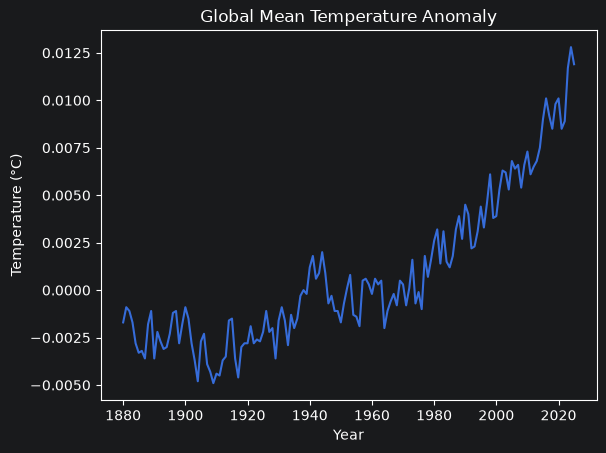

In [48]:
plt.plot(df_clean["Year"], df_clean["Annual_C"])
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Global Mean Temperature Anomaly")
plt.show()

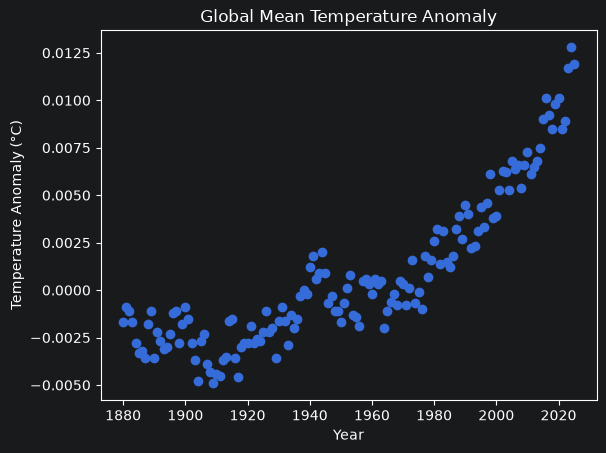

In [49]:
plt.scatter(df_clean["Year"], df_clean["Annual_C"])
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Global Mean Temperature Anomaly")
plt.show()

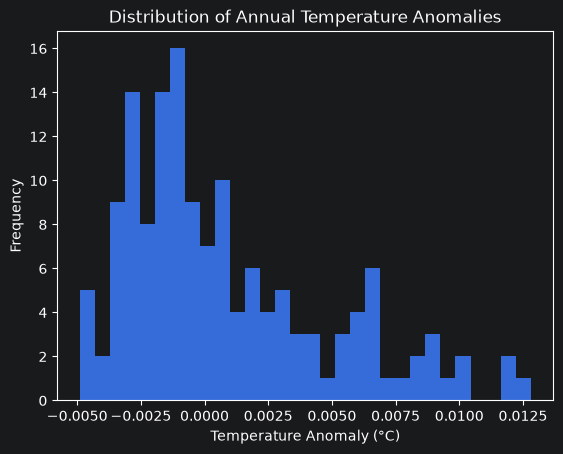

In [50]:
plt.hist(df_clean["Annual_C"], bins=30)
plt.xlabel("Temperature Anomaly (°C)")
plt.ylabel("Frequency")
plt.title("Distribution of Annual Temperature Anomalies")
plt.show()

### Customising plots

By default, Matplotlib automatically assigns a different colour to each line plotted on the same graph. You can override this, as well as customise the line style and width. For a full list of named colours, linestyles, and other options, see the Matplotlib documentation https://matplotlib.org/stable/gallery/index.html.

To identify each line, assign it a label using the `label` argument and call `plt.legend()` after your plot calls. This will automatically display a legend using the labels you have defined.

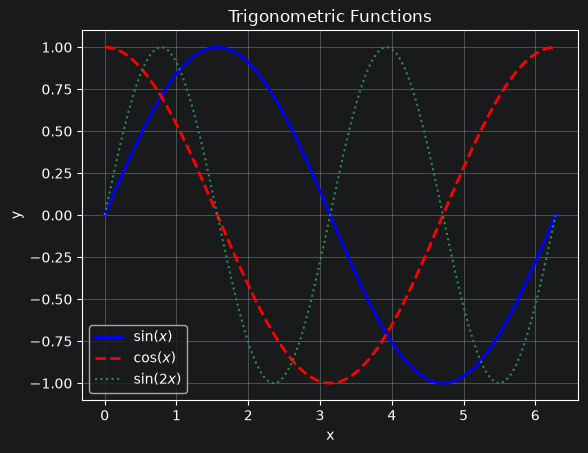

In [51]:
# x axis values
x = np.linspace(0, 2 * np.pi, 100)

# line plots
plt.plot(x, np.sin(x), color="blue", linewidth=2, label=r"$\sin(x)$") # you can use the r before a string to insert latex (without it you get an error)
plt.plot(x, np.cos(x), color="red", linewidth=2, linestyle="--", label=r"$\cos(x)$")
plt.plot(x, np.sin(2 * x), color="seagreen", linewidth=1.5, linestyle=":", label=r"$\sin(2x)$")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Trigonometric Functions")
plt.legend()
plt.grid(True)
plt.show()

To display several plots side by side, use `plt.subplots()`. This creates a figure containing several panels called axes. You specify the number of rows and columns of panels, and Matplotlib returns a fig object (the overall figure) and an axes array (one entry per panel).

To plot into a specific panel, use `axes[i]` instead of `plt.`. Note that the method names change slightly.

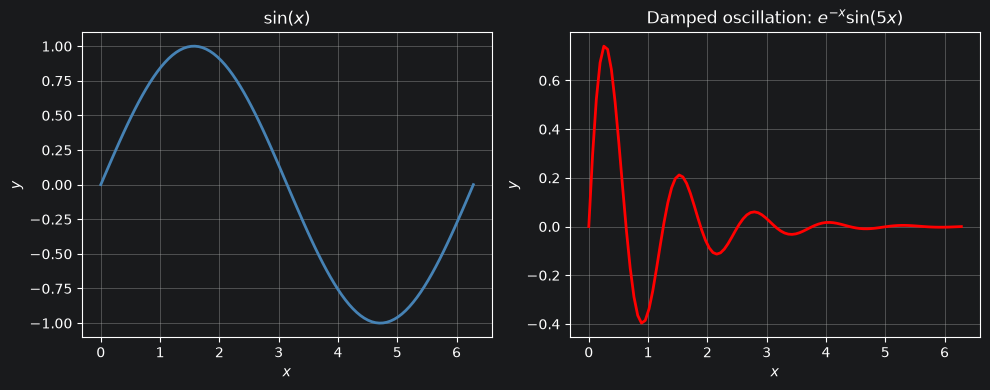

In [52]:
x = np.linspace(0, 2 * np.pi, 100)

# one row, two columns:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# left plot
axes[0].plot(x, np.sin(x), color="steelblue", linewidth=2)
axes[0].set_title(r"$\sin(x)$")
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$y$")
axes[0].grid(True)

# right plot
axes[1].plot(x, np.exp(-x) * np.sin(5 * x), color="red", linewidth=2)
axes[1].set_title(r"Damped oscillation: $e^{-x}\sin(5x)$")
axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel(r"$y$")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Exercises


For the following exercises, assume the dataset has already been loaded and cleaned as in the teaching notebook. Use the DataFrame `df_clean` with an `Annual_C` column in degrees Celsius.

1. Compute the month with the highest mean temperature anomaly across all years. Compute the month which has the lowest.

In [54]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# convert monthly columns to numeric
for month in months:
    df_clean[month] = pd.to_numeric(df_clean[month], errors="coerce")

# compute mean anomaly per month
monthly_means = df_clean[months].mean()

print("Warmest month:", monthly_means.sort_values().index[-1])
print("Coldest month:", monthly_means.sort_values().index[0])

Warmest month: Oct
Coldest month: Jun


2. Write a function `monthly_means(df)` that returns a dictionary mapping each month name to its mean anomaly across all years.

In [55]:
def monthly_means(df):
    """Returns a dictionary mapping each month name to its mean anomaly"""
    months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    output_dict = {}
    for month in months:
        output_dict[month] = df[month].mean()
    return output_dict

monthly_means(df_clean)

{'Jan': np.float64(0.07815068493150686),
 'Feb': np.float64(0.08623287671232878),
 'Mar': np.float64(0.10458904109589043),
 'Apr': np.float64(0.07726027397260271),
 'May': np.float64(0.06568493150684931),
 'Jun': np.float64(0.054041095890410965),
 'Jul': np.float64(0.07712328767123286),
 'Aug': np.float64(0.07726027397260275),
 'Sep': np.float64(0.08356164383561646),
 'Oct': np.float64(0.10801369863013702),
 'Nov': np.float64(0.10006849315068495),
 'Dec': np.float64(0.07363013698630136)}

3. Using the monthly means computed in Q2, produce a bar plot (see https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html) showing the mean anomaly for each month. Add appropriate axis labels and a title.

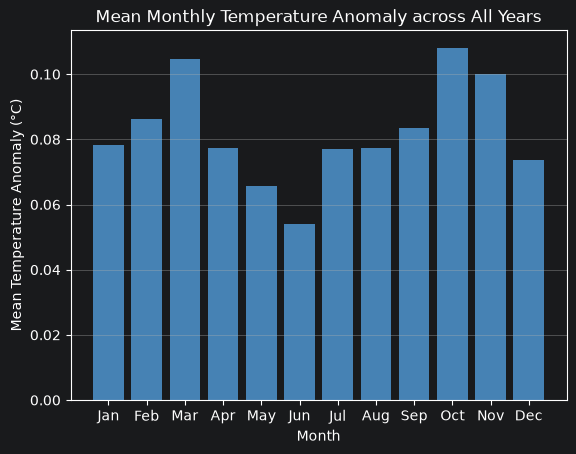

In [56]:
means = monthly_means(df_clean)

plt.bar(means.keys(), means.values(), color="steelblue")
plt.xlabel("Month")
plt.ylabel("Mean Temperature Anomaly (°C)")
plt.title("Mean Monthly Temperature Anomaly across All Years")
plt.grid(axis="y")
plt.show()

4. Pick any three years of your choice and plot their monthly anomaly profiles (Jan–Dec) as three lines on one graph. Add a legend and grid.

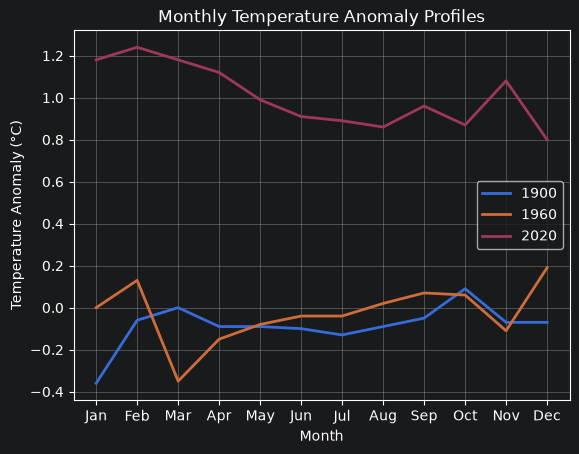

In [57]:
years = [1900, 1960, 2020]

for year in years:
    row = df_clean[df_clean["Year"] == year][months].values.flatten()
    plt.plot(months, row, linewidth=2, label=str(year))

plt.xlabel("Month")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Monthly Temperature Anomaly Profiles")
plt.legend()
plt.grid(True)
plt.show()

5. Write a function `fourier_square(x, N)` that takes an array of $x$ values and a number of terms $N$ and returns the Fourier series approximation:

$$ f(x) = \frac{4}{\pi} \sum_{k = 1,3,5,\ldots }^{N} \frac{\sin(kx)}{k} $$

In [58]:
def fourier_square(x, N):
    """Return the Fourier series approximation of a square wave"""
    result = np.zeros_like(x, dtype=float)
    for k in range(1, N + 1, 2):  # odd values only
        result += np.sin(k * x) / k
    return (4 / np.pi) * result

6. Create a figure with four subplots $(2 \times 2)$ showing the approximation for $N = 1, 5, 25, 100$. Use the same $y$-axis limits across all subplots.

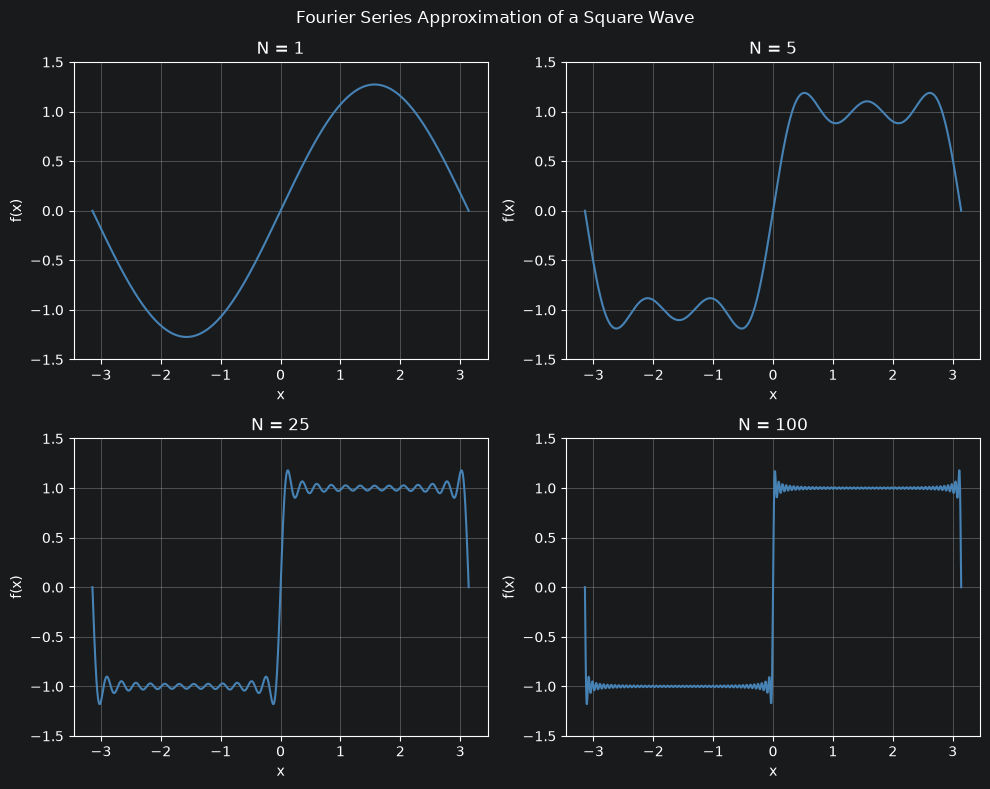

In [59]:
x = np.linspace(-np.pi, np.pi, 1000)
terms = [1, 5, 25, 100]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()  # we convert the 2x2 array of axes to a flat array for easier indexing

for i, N in enumerate(terms):
    axes[i].plot(x, fourier_square(x, N), color="steelblue", linewidth=1.5)
    axes[i].set_title(f"N = {N}")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("f(x)")
    axes[i].set_ylim(-1.5, 1.5)
    axes[i].grid(True)

plt.suptitle("Fourier Series Approximation of a Square Wave")
plt.tight_layout()
plt.show()